In [637]:
import pandas as pd
import numpy as np
from sklearn import linear_model

Categorical variables: CarName, fueltype, aspiration, doornumber, carbody, drivewheel, enginelocation, enginetype, cylindernumber, fuelsystem
Numerical variables: wheelbase, carlength, carwidth, carheight, curbweight, enginesize, boreratio, stroke, compression, horsepower, peakrpm, citympg, highwaympg
Dependent variables: price


--> it seems that i might be able to remove some variables from this. how would i remove variables? remove based on correlation? what correlation is good enough to remove?

In [638]:
df = pd.read_csv(r"C:\Users\achyu\git\statProjects\CarPriceRegression\archive\CarPrice_Assignment.csv")
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [639]:
#fitting with numerical variables
reg = linear_model.LinearRegression()
reg.fit(df[["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "boreratio", "stroke", "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg"]].values, df.price.values)

LinearRegression()

In [640]:
print(reg.coef_)
print(reg.intercept_)

[ 1.22616924e+02 -9.46751865e+01  5.05571630e+02  1.63180142e+02
  1.88462209e+00  1.17346080e+02 -1.00256542e+03 -3.03460602e+03
  2.98136931e+02  3.08085941e+01  2.37513582e+00 -3.20354533e+02
  2.02822067e+02]
-47495.74059538069


In [641]:
#error of model using numerical predictors
from sklearn.metrics import mean_squared_error

actual = list(df.price)
predY = reg.predict(df[["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "boreratio", "stroke", "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg"]].values)
rmse = mean_squared_error(actual, predY, squared=False)
print(rmse)

3078.3467568920223


In [642]:
#feature selection using variance threshold
from sklearn.feature_selection import VarianceThreshold
numericalPredictors = df[["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "boreratio", "stroke", "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg"]]
priceList = df.iloc[:, -1]

In [643]:
#split into train and test
from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(numericalPredictors, priceList, test_size = 0.3, random_state = 123)
#removing predictors if their variance is less that or equal to the threshold set below
selector = VarianceThreshold(threshold = 0.5)
selector.fit(xTrain)
#how to set an optimal threshold?

VarianceThreshold(threshold=0.5)

In [644]:
selector.get_support()

array([ True,  True,  True,  True,  True,  True, False, False,  True,
        True,  True,  True,  True])

If any of the value above were false, then we can use the df.drop function to drop as those are redundant predictors

In [645]:
numericalPredictors = df[["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg"]]
from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(numericalPredictors, priceList, test_size = 0.3, random_state=10)
selector = VarianceThreshold(threshold = 0.5)
selector.fit(xTrain)
selector.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [646]:
xTrain, yTrain

(     wheelbase  carlength  carwidth  carheight  curbweight  enginesize  \
 43        94.3      170.7      61.8       53.5        2337         111   
 78        93.7      157.3      64.4       50.8        2004          92   
 143       97.2      172.0      65.4       52.5        2340         108   
 21        93.7      157.3      63.8       50.8        1876          90   
 128       89.5      168.9      65.0       51.6        2800         194   
 ..         ...        ...       ...        ...         ...         ...   
 113      114.2      198.9      68.4       56.7        3285         120   
 64        98.8      177.8      66.5       55.5        2425         122   
 15       103.5      189.0      66.9       55.7        3230         209   
 125       94.5      168.9      68.3       50.2        2778         151   
 9         99.5      178.2      67.9       52.0        3053         131   
 
      compressionratio  horsepower  peakrpm  citympg  highwaympg  
 43               8.50         

In [647]:
xTest, yTest

(     wheelbase  carlength  carwidth  carheight  curbweight  enginesize  \
 131       96.1      176.8      66.6       50.5        2460         132   
 117      108.0      186.7      68.3       56.0        3130         134   
 63        98.8      177.8      66.5       55.5        2443         122   
 56        95.3      169.0      65.7       49.6        2380          70   
 49       102.0      191.7      70.6       47.8        3950         326   
 ..         ...        ...       ...        ...         ...         ...   
 190       94.5      165.7      64.0       51.4        2221         109   
 204      109.1      188.8      68.9       55.5        3062         141   
 72        96.6      180.3      70.5       50.8        3685         234   
 130       96.1      181.5      66.5       55.2        2579         132   
 24        93.7      157.3      63.8       50.6        1967          90   
 
      compressionratio  horsepower  peakrpm  citympg  highwaympg  
 131               8.7         

In [648]:
reg2 = linear_model.LinearRegression()
reg2.fit(xTrain.values, yTrain.values)
predY2 = reg2.predict(xTest.values)
score2 = reg2.score(xTest.values, yTest.values) #returns accuracy of the model
rootError2 = mean_squared_error(yTest.values, predY2, squared= False)
rootError2, score2

(4195.184333192487, 0.7227529483076076)

In [649]:
#remove multicollinearity
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [650]:
df.dtypes.unique

<bound method Series.unique of car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object>

In [651]:
#get all numerical columns
typesWanted = ["float64", "int64"]
numPredictors = list(df.select_dtypes(include = typesWanted))
print(numPredictors)

['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [652]:
numericalPredictors

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,88.6,168.8,64.1,48.8,2548,130,9.0,111,5000,21,27
1,88.6,168.8,64.1,48.8,2548,130,9.0,111,5000,21,27
2,94.5,171.2,65.5,52.4,2823,152,9.0,154,5000,19,26
3,99.8,176.6,66.2,54.3,2337,109,10.0,102,5500,24,30
4,99.4,176.6,66.4,54.3,2824,136,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952,141,9.5,114,5400,23,28
201,109.1,188.8,68.8,55.5,3049,141,8.7,160,5300,19,25
202,109.1,188.8,68.9,55.5,3012,173,8.8,134,5500,18,23
203,109.1,188.8,68.9,55.5,3217,145,23.0,106,4800,26,27


In [653]:
numericalPredictors2 = df[numPredictors]
numericalPredictors2

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470.0


In [654]:
corrMatrix = xTrain.corr()
corrMatrix

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg
wheelbase,1.000000,0.871552,0.820799,0.581103,0.797975,0.624743,0.083986,0.428707,-0.306851,-0.545264,-0.595535
carlength,0.871552,1.000000,0.849255,0.498237,0.886813,0.695872,0.021658,0.621047,-0.234017,-0.711303,-0.726332
carwidth,0.820799,0.849255,1.000000,0.310614,0.870820,0.749576,0.049546,0.664730,-0.178196,-0.676567,-0.710844
carheight,0.581103,0.498237,0.310614,1.000000,0.342978,0.118108,0.181674,-0.021751,-0.267558,-0.132643,-0.170715
curbweight,0.797975,0.886813,0.870820,0.342978,1.000000,0.841456,-0.014743,0.785359,-0.214671,-0.794851,-0.820311
enginesize,0.624743,0.695872,0.749576,0.118108,0.841456,1.000000,-0.082656,0.817298,-0.208772,-0.680038,-0.703491
compressionratio,0.083986,0.021658,0.049546,0.181674,-0.014743,-0.082656,1.000000,-0.293633,-0.378908,0.407757,0.388102
horsepower,0.428707,0.621047,0.664730,-0.021751,0.785359,0.817298,-0.293633,1.000000,0.135985,-0.831492,-0.819465
peakrpm,-0.306851,-0.234017,-0.178196,-0.267558,-0.214671,-0.208772,-0.378908,0.135985,1.000000,-0.090844,-0.057857
citympg,-0.545264,-0.711303,-0.676567,-0.132643,-0.794851,-0.680038,0.407757,-0.831492,-0.090844,1.000000,0.977280


<Axes: >

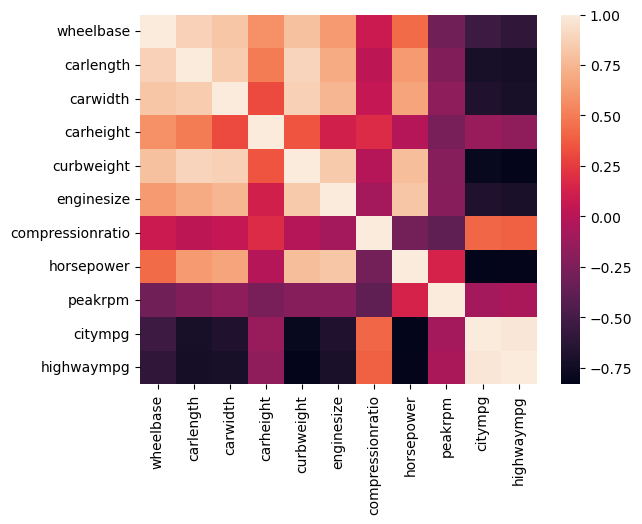

In [655]:
sns.heatmap(corrMatrix)

In [656]:
#we want to set a threshold that if there are variables with 70% correlation, then i want only one so that the model does not overfit
def correlation(df, threshold):
    correlated_cols = set()
    #using set to get only unique elements instead of list or tuple which can have repeats
    corrMatrix = df.corr()
    for i in range(len(corrMatrix.columns)):
        for j in range(i):
            if abs(corrMatrix.iloc[i, j] > threshold):
                columnName = corrMatrix.columns[i]
                correlated_cols.add(columnName)
    return correlated_cols

In [657]:
corrFeatures = correlation(xTrain, 0.7)
corrFeatures

{'carlength',
 'carwidth',
 'curbweight',
 'enginesize',
 'highwaympg',
 'horsepower'}

In [658]:
xTrain.shape, xTest.shape

((143, 11), (62, 11))

In [659]:
xTrain.drop(labels = corrFeatures, axis = 1, inplace = True)
xTest.drop(labels = corrFeatures, axis = 1, inplace = True)
xTrain.shape, xTest.shape

((143, 5), (62, 5))

In [660]:
#using chi square test to do feature selection for categorical variables
from sklearn.feature_selection import chi2
#get all categorical columns
typesWanted2 = ["object"]
catPredictors = df.select_dtypes(include = typesWanted2)
catPredictorsList = list(df.select_dtypes(include = typesWanted2))
print(catPredictorsList)

['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [661]:
catPredictors

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [662]:
#ordinal encoder to change categorical variables into some dummy numbers
catPredictors.nunique()

CarName           147
fueltype            2
aspiration          2
doornumber          2
carbody             5
drivewheel          3
enginelocation      2
enginetype          7
cylindernumber      7
fuelsystem          8
dtype: int64

In [663]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
encoder.fit(catPredictors[['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody','drivewheel', 'enginelocation', 'enginetype', 'cylindernumber','fuelsystem']])

OrdinalEncoder()

In [664]:
catPredictors.columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

In [665]:
df.isna().sum() #checking for missing values, if we find any, we will drop

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [666]:
catPredictors[['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody','drivewheel', 'enginelocation', 'enginetype', 'cylindernumber','fuelsystem']] = encoder.transform(catPredictors[['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody','drivewheel', 'enginelocation', 'enginetype', 'cylindernumber','fuelsystem']])

In [667]:
#catPredictors = pd.DataFrame(catPredictorsNP, columns = catPredictorsList)
catPredictors.head()

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,2.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,2.0,5.0
1,3.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,2.0,5.0
2,1.0,1.0,0.0,1.0,2.0,2.0,0.0,5.0,3.0,5.0
3,4.0,1.0,0.0,0.0,3.0,1.0,0.0,3.0,2.0,5.0
4,5.0,1.0,0.0,0.0,3.0,0.0,0.0,3.0,1.0,5.0


In [668]:
catPredictors.nunique()

CarName           147
fueltype            2
aspiration          2
doornumber          2
carbody             5
drivewheel          3
enginelocation      2
enginetype          7
cylindernumber      7
fuelsystem          8
dtype: int64

In [669]:
x = catPredictors.iloc[:,:]
y = df.price.values
xTrain2, xTest2, yTrain2, yTest2 = train_test_split(x.values, y, test_size = 0.3, random_state = 10)

In [670]:
fScore = chi2(xTrain2, yTrain2)

ValueError: Unknown label type: (array([ 6785.   ,  6669.   ,  9960.   ,  5572.   , 37028.   , 18399.   ,
        7099.   ,  5118.   ,  9258.   , 18950.   , 25552.   , 18344.   ,
        6377.   ,  9095.   , 19045.   ,  6229.   ,  9298.   , 19699.   ,
       15690.   ,  7975.   ,  9279.   , 11199.   , 10698.   , 12945.   ,
        9959.   ,  8499.   ,  5399.   , 18420.   , 35550.   ,  6692.   ,
        6695.   , 15580.   , 36880.   ,  7957.   ,  6095.   , 24565.   ,
       12629.   , 14489.   , 11595.   , 12964.   , 13950.   ,  7957.   ,
       16515.   , 12290.   ,  7895.   , 12940.   ,  9639.   , 13845.   ,
        8916.5  ,  7463.   ,  7999.   ,  7995.   ,  6692.   , 12440.   ,
       10345.   , 11850.   , 15040.   ,  7689.   , 15985.   , 13295.   ,
        9989.   ,  7775.   ,  7775.   , 17669.   , 20970.   , 16900.   ,
       16925.   ,  6989.   , 18150.   ,  6488.   , 17199.   ,  7129.   ,
       13200.   ,  5195.   ,  9988.   ,  8013.   , 11694.   , 17450.   ,
       12170.   , 